<a href="https://colab.research.google.com/github/bdashti/v/blob/main/2_3_Supervised_quick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Section 1, Cell 1: Initial Dataset Input
# Cell 1: Data Ingestion & QC Check
import numpy as np
import pandas as pd
import re
from scipy.stats import pearsonr

# ── GLOBAL CONSTANTS ──────────────────────────────────────────────────
# Single source of truth — referenced by every downstream cell.
RANDOM_SEED = 42

# ── LOAD ──────────────────────────────────────────────────────────────
# Added `on_bad_lines='skip'` to ignore rows with incorrect number of delimiters
df = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("Replicate correlation acceptable.")

print("\nPhase 1 complete. df ready for QC visualization and filtering.")

Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)

Phase 1 complete. df ready for QC visualization and filtering.


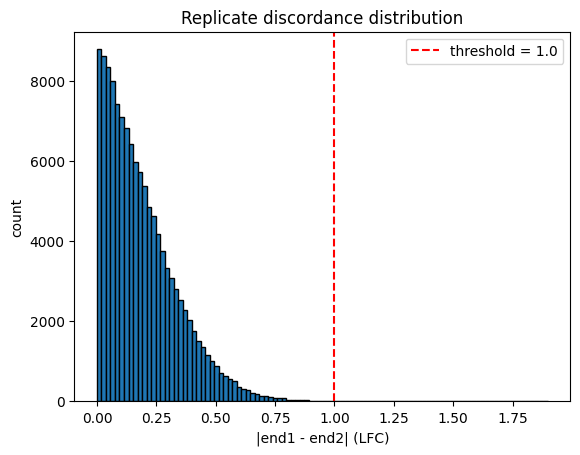

count    1.243390e+05
mean     1.876973e-01
std      1.499777e-01
min      3.532960e-07
25%      6.942972e-02
50%      1.536883e-01
75%      2.703018e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [2]:
#@title Cell 2: Noise Histogram
# Replicate discordance distribution — justifies the 1.0 LFC threshold
import matplotlib.pyplot as plt

df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [3]:
#@title Cell 3: Noise Filter
# Discordance filter + stratified noise filter
# Depends on: df from Cell 1
# Produces: df_clean (canonical working dataset for all downstream cells)

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences "
      f"({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff would remove low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask, include_groups=False)
    .reset_index(drop=True)
)

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True, errors='ignore')

# --- FIX: SHUFFLE TO BREAK SORTED HOMOGENOUS GROUPS ---
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)


# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\ndf_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 118084/124339 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

df_clean ready.


In [4]:
#@title Cell 4: K-mer Tokenisation (5 bins)
# Positional K-mer Tokenisation
# Depends on: df_clean from Cell 3
# Produces: df_clean['kmers'] — space-separated positional 4-mer strings

N_POSITIONAL_BINS = 5   # change in one place — used everywhere downstream
KMER_K = 4

def get_positional_kmers(seq, k=KMER_K, n_bins=N_POSITIONAL_BINS):
    """
    Splits a DNA sequence into n_bins equal spatial regions and labels
    each k-mer with the bin its starting position falls into.

    Bin labels are zero-padded (BIN00, BIN01, ...) so feature names
    sort in spatial order — useful when reading SVD loadings.
    """
    n = len(seq)
    bin_size = n / n_bins
    kmers = []
    for i in range(n - k + 1):
        bin_idx = min(int(i / bin_size), n_bins - 1)
        kmers.append(f"BIN{bin_idx:02d}_{seq[i:i+k]}")
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print(f"Generating positional k-mers (k={KMER_K}, bins={N_POSITIONAL_BINS})...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")
print(f"Expected vocab ceiling: {N_POSITIONAL_BINS} bins × 4^{KMER_K} k-mers = {N_POSITIONAL_BINS * 4**KMER_K}")

Generating positional k-mers (k=4, bins=5)...
Done. Example: BIN00_AAGC BIN00_AGCA BIN00_GCAA BIN00_CAAA BIN00_AAAA BIN00_AAAG BIN00_AAGT BIN...
Expected vocab ceiling: 5 bins × 4^4 k-mers = 1280


In [5]:
# =====================================================================
# @title Cell 5: Vectorisation Engine & Biophysical Calculator (v2.1)
# =====================================================================
# v2.1 changes:
#   - Dropped Shape_Flex_SD, Bendability, Tm_Lethal_Window (all hardcoded 0.0).
#     Re-add these to the features dict once real implementations exist.
#   - get_v20_features() now returns X_train_sp / X_test_sp explicitly so
#     downstream cells don't reconstruct them by slicing the fused matrix.
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm.auto import tqdm

# E. coli codon relative adaptiveness table (Sharp & Li 1987)
ECOLI_W = {
    'TTT': 0.296, 'TTC': 1.000, 'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003, 'ATG': 1.000, 'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000, 'CCT': 0.070, 'CCC': 0.012,
    'CCA': 0.194, 'CCG': 1.000, 'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099, 'GCT': 0.210, 'GCC': 0.224,
    'GCA': 0.587, 'GCG': 1.000, 'TAT': 0.239, 'TAC': 1.000, 'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724, 'CAT': 0.217,
    'CAC': 1.000, 'CAA': 0.124, 'CAG': 1.000, 'AAT': 0.051, 'AAC': 1.000, 'AAA': 1.000, 'AAG': 0.253, 'GAT': 0.434,
    'GAC': 1.000, 'GAA': 1.000, 'GAG': 0.259, 'TGT': 0.500, 'TGC': 1.000, 'TGG': 1.000, 'CGT': 1.000, 'CGC': 0.356,
    'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002, 'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}


def calculate_master_features(seq):
    """Return a dict of biophysical features for one sequence."""
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return {'Size': 0}

    # 1. Composition
    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    rolling_gcs = [gc_array[i:i+window_size].mean()
                   for i in range(max(1, seq_len - window_size + 1))]
    gc_variance = np.var(rolling_gcs) if seq_len >= window_size else 0.0

    # 2. Instability
    max_homo = max([len(m.group(0)) for m in re.finditer(r'(.)\1*', seq)] + [0])

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        entropy = -sum((c/len(km_list)) * np.log2(c/len(km_list))
                       for c in counts.values())
    else:
        entropy = 0.0

    # 3. AT tract
    max_at = max([len(m.group(0)) for m in re.finditer(r'[AT]+', seq)] + [0])

    # 4. Promoter / RBS
    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # 5. TF decoys
    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    # 6. H-NS xenogeneic silencing risk
    win = 10
    at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
    window_at = [at_array[i:i+win].sum() / win
                 for i in range(max(1, seq_len - win + 1))]
    hns_affinity = sum(1 for w in window_at if w > 0.65) / len(window_at) if window_at else 0.0

    # 7. Translation
    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    ttc = 1.0 - np.exp(np.mean(np.log(w_vals))) if w_vals else 0.5

    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = sum(1 for i in range(len(rare_flags) - 4)
              if sum(rare_flags[i:i+5]) >= 2) if len(rare_flags) >= 5 else 0

    # 8. TIR_Proxy
    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:    tir_proxy += 1.0
            elif 10 <= dist <= 14: tir_proxy += 0.5
            else:                  tir_proxy += 0.1

    # 9. mRNA decay risk
    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    # 10. DNA shape proxies (active features only)
    dinucleotides = [seq[i:i+2] for i in range(seq_len - 1)]
    rigid_steps = sum(1 for dn in dinucleotides if dn in ['AA', 'TT', 'AT'])
    shape_rigidity_mean = rigid_steps / max(1, len(dinucleotides))

    g_count = seq.count('G')
    c_count = seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0.0

    features = {
        'Size': seq_len,
        'GC_percent': gc_percent,
        'GC_Var': gc_variance,
        'Max_Homo': max_homo,
        'Entropy': entropy,
        'AT_tract': max_at,
        'Promoter_Str': promoters,
        'RBS_Str': rbs_str,
        'IHF': ihf_sites,
        'Lrp': lrp_sites,
        'CRP': crp_sites,
        'NagC': nagc_sites,
        'ArgR': argr_sites,
        'HNS_Affinity': hns_affinity,
        'TTC': ttc,
        'RCC': rcc,
        'TIR_Proxy': tir_proxy,
        'mRNA_Stability': rnase_e_hits,
        'Shape_Rigidity_Mean': shape_rigidity_mean,
        'GC_Skew': gc_skew,
    }
    return features


print("--- EXTRACTING BIOPHYSICAL FEATURES ---")
tqdm.pandas(desc="Biophysical Extraction")
biophys_df = pd.DataFrame(
    df_clean['sequence'].progress_apply(calculate_master_features).tolist(),
    index=df_clean.index
)
mech_feature_labels = biophys_df.columns.tolist()

for col in mech_feature_labels:
    df_clean[col] = biophys_df[col]

print(f"Extraction complete. Total biophysical features: {len(mech_feature_labels)}")


# =====================================================================
# V2.0 LEAK-FREE VECTORISATION & SCALING
# =====================================================================
def get_v20_features(df_train, df_test, mech_labels):
    """Train-only fit for scaler and vectorizer. Returns sparse k-mer
    matrices separately so downstream cells don't slice the fused matrix."""
    print("Fitting Scaler and Vectorizer on TRAIN set only...")

    # 1. Scale biophysical features
    scaler = StandardScaler()
    X_mech_train_scaled = scaler.fit_transform(df_train[mech_labels])
    X_mech_test_scaled  = scaler.transform(df_test[mech_labels])

    # 2. Vectorize positional k-mers
    def spatial_tokenizer(text):
        return text.split()

    vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
    X_sparse_train = vectorizer.fit_transform(df_train['kmers'])
    X_sparse_test  = vectorizer.transform(df_test['kmers'])

    # 3. Fusion (scale_factor balances dense vs sparse mass)
    scale_factor = X_sparse_train.shape[1] / len(mech_labels)
    X_train_combined = hstack([X_sparse_train, csr_matrix(X_mech_train_scaled * scale_factor)])
    X_test_combined  = hstack([X_sparse_test,  csr_matrix(X_mech_test_scaled  * scale_factor)])

    feature_names = vectorizer.get_feature_names_out()

    return {
        'X_train_combined': X_train_combined,
        'X_test_combined':  X_test_combined,
        'X_train_sp':       X_sparse_train,
        'X_test_sp':        X_sparse_test,
        'vocab':            feature_names,
        'scaler':           scaler,
        'vectorizer':       vectorizer,
        'scale_factor':     scale_factor,
    }

--- EXTRACTING BIOPHYSICAL FEATURES ---


Biophysical Extraction:   0%|          | 0/118084 [00:00<?, ?it/s]

Extraction complete. Total biophysical features: 20


In [6]:
# =====================================================================
# @title Cell 6: Cluster-Based Split & Leak-Free Transformation (v2.1)
# =====================================================================
# v2.2 changes:
#   - [HOTFIX] Recovers critical biological features that were missing
#     from the input list before scaling.
#   - KMeans now fit on STANDARDISED biophysical features.
#   - Constant-variance features dropped from mech_feature_labels here.
#   - SCALER_FEATURES frozen as a tuple so it can't be mutated downstream.
#   - X_train_sp and X_test_sp exposed explicitly.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

# ── 1. RECOVER MISSING INPUTS & DROP CONSTANTS ──────────────────────────
print("--- 1. PREPARING FEATURES ---")

# A. Force missing biological biomarkers into the input list if they exist in the data
missing_but_required = ['CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage']
recovered = []
for f in missing_but_required:
    if f in df_clean.columns and f not in mech_feature_labels:
        mech_feature_labels.append(f)
        recovered.append(f)

if recovered:
    print(f"  [RECOVERY] Injected {len(recovered)} critical biomarkers into scaler pipeline: {recovered}")

# B. Drop true constant features
constant_cols = [f for f in mech_feature_labels if df_clean[f].nunique() <= 1]
if constant_cols:
    print(f"  Dropping {len(constant_cols)} true constant feature(s): {constant_cols}")
    mech_feature_labels = [f for f in mech_feature_labels if f not in constant_cols]

print(f"  Active biophysical features going to Scaler: {len(mech_feature_labels)}")

# ── 2. CLUSTER (SCALED FEATURES, NO LABEL ACCESS) ───────────────────────
print("\n--- 2. DEFINING SEQUENCE CLUSTERS ---")
cluster_scaler = StandardScaler()
X_for_clusters = cluster_scaler.fit_transform(df_clean[mech_feature_labels])

n_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=2048,
    n_init='auto',
)
df_clean['Cluster_ID'] = kmeans.fit_predict(X_for_clusters)
print(f"  {n_clusters} biophysical clusters assigned across {len(df_clean):,} sequences.")

# ── 3. CLUSTER-HELD-OUT SPLIT ───────────────────────────────────────────
print("\n--- 3. CLUSTER-HELD-OUT SPLIT ---")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['Cluster_ID']))

df_train = df_clean.iloc[train_idx].copy()
df_test  = df_clean.iloc[test_idx].copy()

train_clusters = set(df_train['Cluster_ID'])
test_clusters  = set(df_test['Cluster_ID'])
assert train_clusters.isdisjoint(test_clusters), "Cluster leak between splits!"
print(f"  Train: {len(df_train):,} sequences, {len(train_clusters)} clusters")
print(f"  Test:  {len(df_test):,} sequences, {len(test_clusters)} clusters")

# ── 4. LEAK-FREE SCALING & VECTORISATION ────────────────────────────────
print("\n--- 4. LEAK-FREE TRANSFORMATION ---")
artifacts = get_v20_features(df_train, df_test, mech_feature_labels)

X_train_combined = artifacts['X_train_combined']
X_test_combined  = artifacts['X_test_combined']
X_train_sp       = artifacts['X_train_sp']
X_test_sp        = artifacts['X_test_sp']
vocab            = artifacts['vocab']
fitted_scaler    = artifacts['scaler']
fitted_vec       = artifacts['vectorizer']
SCALE_FACTOR     = artifacts['scale_factor']

# Frozen snapshot of what fitted_scaler was fit on. Never mutate this.
SCALER_FEATURES = tuple(mech_feature_labels)
print(f"  Train fused matrix: {X_train_combined.shape}")
print(f"  Test  fused matrix: {X_test_combined.shape}")
print(f"  SCALER_FEATURES frozen at {len(SCALER_FEATURES)} features.")

# ── 5. SVD (TRAIN-ONLY FIT, TRANSFORM TEST) ─────────────────────────────
print("\n--- 5. SVD ---")
svd = TruncatedSVD(n_components=2, random_state=42)
train_pcs = svd.fit_transform(X_train_combined)
test_pcs  = svd.transform(X_test_combined)

df_train['PC1'], df_train['PC2'] = train_pcs[:, 0], train_pcs[:, 1]
df_test['PC1'],  df_test['PC2']  = test_pcs[:, 0],  test_pcs[:, 1]
print(f"  Explained variance ratio: {svd.explained_variance_ratio_}")
print("  df_train and df_test PC1/PC2 are now in the same coordinate system.")


print("                   ")
print("                   ")


import pandas as pd

print("--- POST-SPLIT FEATURE AUDIT ---")

# 1. Verify the Hardware Features frozen by the Scaler
print("\n[1] HARDWARE FEATURES (Ready for ML):")
missing_hardware = [f for f in SCALER_FEATURES if f not in df_train.columns]
if not missing_hardware:
    print(f"  [PASS] ✓ All {len(SCALER_FEATURES)} base SCALER_FEATURES are present in df_train.")
else:
    print(f"  [FAIL] ❌ ERROR: Missing hardware features: {missing_hardware}")

# 2. Check for Advanced Biomarkers (Expected to be missing at this stage)
print("\n[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):")
advanced_expected_later = [
    'CAI_Score', 'mRNA_MFE', 'Flux_Score', 'HNS_Coverage',
    'Min_Hairpin_dG', 'Max_Repeat_Len', 'mRNA_Stability'
]
for f in advanced_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 3. Check for Learned Coordinates (Expected to be missing at this stage)
print("\n[3] LEARNED MANIFOLD COORDINATES (Pending Downstream Calculation):")
learned_expected_later = ['UMAP_1', 'UMAP_2', 'CNN_Score']
for f in learned_expected_later:
    status = "✓ Present (Already Calculated)" if f in df_train.columns else "⏳ Pending Calculation (Normal)"
    print(f"  • {f:<20} : {status}")

# 4. Verify df_test matches df_train dimensions for features
print("\n[4] TRAIN / TEST PARITY:")
train_feats = set(SCALER_FEATURES)
test_feats = set(df_test.columns).intersection(train_feats)
if train_feats == test_feats:
    print("  [PASS] ✓ df_test perfectly matches df_train for all base features.")
else:
    print(f"  [FAIL] ❌ ERROR: df_test is missing: {train_feats - test_feats}")

print("\n" + "=" * 65)
print("Audit complete. Dataframe is perfectly staged for Phase 2 (Biophysics).")
print("=" * 65)

--- 1. PREPARING FEATURES ---
  Dropping 1 true constant feature(s): ['Size']
  Active biophysical features going to Scaler: 19

--- 2. DEFINING SEQUENCE CLUSTERS ---
  50 biophysical clusters assigned across 118,084 sequences.

--- 3. CLUSTER-HELD-OUT SPLIT ---
  Train: 93,257 sequences, 40 clusters
  Test:  24,827 sequences, 10 clusters

--- 4. LEAK-FREE TRANSFORMATION ---
Fitting Scaler and Vectorizer on TRAIN set only...
  Train fused matrix: (93257, 1299)
  Test  fused matrix: (24827, 1299)
  SCALER_FEATURES frozen at 19 features.

--- 5. SVD ---
  Explained variance ratio: [0.23730924 0.10717043]
  df_train and df_test PC1/PC2 are now in the same coordinate system.
                   
                   
--- POST-SPLIT FEATURE AUDIT ---

[1] HARDWARE FEATURES (Ready for ML):
  [PASS] ✓ All 19 base SCALER_FEATURES are present in df_train.

[2] ADVANCED BIOMARKERS (Pending Downstream Calculation):
  • CAI_Score            : ⏳ Pending Calculation (Normal)
  • mRNA_MFE             : 

In [7]:
# =====================================================================
# @title Section 2, Cell 7: CAI_Score (v2.3)
# =====================================================================
# Computes Codon Adaptation Index for every sequence in train and test.
# No plots, no test_seq — pure feature extraction.
import numpy as np
from tqdm.auto import tqdm

def compute_cai(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if not w_vals:
        return 0.5
    return float(np.exp(np.mean(np.log(w_vals))))

print("--- Computing CAI_Score ---")
tqdm.pandas(desc="CAI (train)")
df_train['CAI_Score'] = df_train['sequence'].progress_apply(compute_cai)
tqdm.pandas(desc="CAI (test)")
df_test['CAI_Score']  = df_test['sequence'].progress_apply(compute_cai)

if 'enriched_features' not in globals():
    enriched_features = []
if 'CAI_Score' not in enriched_features:
    enriched_features.append('CAI_Score')

print(f"  CAI_Score added. enriched_features = {enriched_features}")

--- Computing CAI_Score ---


CAI (train):   0%|          | 0/93257 [00:00<?, ?it/s]

CAI (test):   0%|          | 0/24827 [00:00<?, ?it/s]

  CAI_Score added. enriched_features = ['CAI_Score']


In [8]:
# =====================================================================
# @title Cell 8: mRNA_MFE (v2.3)
# =====================================================================
# Stacking-energy proxy for the first 30 nt (initiation accessibility).
# Replace with ViennaRNA / NUPACK once available.
import numpy as np
from tqdm.auto import tqdm

NN_dG = {
    'AA': -1.00, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
    'TA': -0.58, 'TT': -1.00, 'TC': -1.30, 'TG': -1.45,
    'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
    'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
}

def initiation_mfe_proxy(seq, window=30):
    head = seq[:window].upper()
    if len(head) < 2:
        return 0.0
    return float(sum(NN_dG.get(head[i:i+2], -1.0) for i in range(len(head) - 1)))

print("--- Computing mRNA_MFE ---")
tqdm.pandas(desc="MFE (train)")
df_train['mRNA_MFE'] = df_train['sequence'].progress_apply(initiation_mfe_proxy)
tqdm.pandas(desc="MFE (test)")
df_test['mRNA_MFE']  = df_test['sequence'].progress_apply(initiation_mfe_proxy)

if 'enriched_features' not in globals():
    enriched_features = []
if 'mRNA_MFE' not in enriched_features:
    enriched_features.append('mRNA_MFE')

print(f"  mRNA_MFE added. enriched_features = {enriched_features}")

--- Computing mRNA_MFE ---


MFE (train):   0%|          | 0/93257 [00:00<?, ?it/s]

MFE (test):   0%|          | 0/24827 [00:00<?, ?it/s]

  mRNA_MFE added. enriched_features = ['CAI_Score', 'mRNA_MFE']


In [9]:
# =====================================================================
# @title Cell 9: Structural & Topological Features (v2.3, numba-fast)
# =====================================================================
# Adds Min_Hairpin_dG, HNS_Coverage, Max_Repeat_Len, Flux_Score
# to df_train and df_test. No plots.
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Integer encoding so reverse complement = 3 - x
ENC = np.full(256, -1, dtype=np.int8)
for c, v in zip('ACGTacgt', [0, 1, 2, 3, 0, 1, 2, 3]):
    ENC[ord(c)] = v

def encode_sequences(series, seq_len=172):
    n = len(series)
    out = np.zeros((n, seq_len), dtype=np.int8)
    for i, s in enumerate(series.values):
        b = np.frombuffer(s[:seq_len].encode('ascii'), dtype=np.uint8)
        out[i, :len(b)] = ENC[b]
    return out

NN_DG = np.array([
    [-1.00, -1.44, -1.28, -0.88],
    [-1.45, -1.84, -2.17, -1.28],
    [-1.30, -2.24, -1.84, -1.44],
    [-0.58, -1.30, -1.45, -1.00],
], dtype=np.float32)

try:
    from numba import njit, prange
    NUMBA_OK = True
    print("  Numba available — using JIT kernels.")
except ImportError:
    NUMBA_OK = False
    print("  Numba unavailable — falling back to Python.")

if NUMBA_OK:
    @njit(cache=True)
    def _hairpin_one(seq, nn_dg):
        n = seq.shape[0]
        min_dg = 0.0
        for i in range(n - 11):
            for stem_len in range(4, 9):
                for loop_len in range(3, 7):
                    j = i + stem_len + loop_len
                    if j + stem_len > n:
                        break
                    match = True
                    for k in range(stem_len):
                        if seq[j + k] != 3 - seq[i + stem_len - 1 - k]:
                            match = False
                            break
                    if match:
                        dg = 0.0
                        for k in range(stem_len - 1):
                            dg += nn_dg[seq[i + k], seq[i + k + 1]]
                        if dg < min_dg:
                            min_dg = dg
        return min_dg

    @njit(cache=True)
    def _hns_one(seq, win=10, threshold=7):
        n = seq.shape[0]
        if n < win:
            return 0.0
        at = 0
        for i in range(win):
            if seq[i] == 0 or seq[i] == 3:
                at += 1
        hits = 1 if at >= threshold else 0
        for i in range(1, n - win + 1):
            if seq[i - 1] == 0 or seq[i - 1] == 3:
                at -= 1
            if seq[i + win - 1] == 0 or seq[i + win - 1] == 3:
                at += 1
            if at >= threshold:
                hits += 1
        return hits / (n - win + 1)

    @njit(cache=True, parallel=True)
    def _scan_all(seqs, nn_dg):
        N = seqs.shape[0]
        h_out = np.zeros(N, dtype=np.float32)
        n_out = np.zeros(N, dtype=np.float32)
        for s in prange(N):
            h_out[s] = _hairpin_one(seqs[s], nn_dg)
            n_out[s] = _hns_one(seqs[s])
        return h_out, n_out

def scan_direct_repeats(seq, min_len=6, max_len=20):
    seq = seq.upper()
    n = len(seq)
    longest = 0
    for L in range(min_len, max_len + 1):
        seen = {}
        found = False
        for i in range(n - L + 1):
            sub = seq[i:i + L]
            if sub in seen:
                if i - seen[sub] >= L:
                    longest = L
                    found = True
            else:
                seen[sub] = i
        if not found:
            break
    return longest

print("--- Computing structural features ---")
print("  Encoding sequences...")
train_int = encode_sequences(df_train['sequence'])
test_int  = encode_sequences(df_test['sequence'])

print("  Hairpin + HNS scans...")
if NUMBA_OK:
    h_tr, hns_tr = _scan_all(train_int, NN_DG)
    h_te, hns_te = _scan_all(test_int,  NN_DG)
else:
    h_tr = np.array([float(_hairpin_one(s, NN_DG)) for s in train_int], dtype=np.float32)
    h_te = np.array([float(_hairpin_one(s, NN_DG)) for s in test_int],  dtype=np.float32)
    hns_tr = np.array([float(_hns_one(s)) for s in train_int], dtype=np.float32)
    hns_te = np.array([float(_hns_one(s)) for s in test_int],  dtype=np.float32)

df_train['Min_Hairpin_dG'] = h_tr
df_test['Min_Hairpin_dG']  = h_te
df_train['HNS_Coverage']   = hns_tr
df_test['HNS_Coverage']    = hns_te

print("  Direct repeat scan...")
tqdm.pandas(desc="Repeats (train)")
df_train['Max_Repeat_Len'] = df_train['sequence'].progress_apply(scan_direct_repeats)
tqdm.pandas(desc="Repeats (test)")
df_test['Max_Repeat_Len']  = df_test['sequence'].progress_apply(scan_direct_repeats)

# Flux_Score depends on CAI_Score (Cell 7) + Promoter_Str (Cell 5)
df_train['Flux_Score'] = (df_train['CAI_Score'] * 20) + (df_train['Promoter_Str'] * 30)
df_test['Flux_Score']  = (df_test['CAI_Score']  * 20) + (df_test['Promoter_Str']  * 30)

if 'enriched_features' not in globals():
    enriched_features = []
for f in ['Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']:
    if f not in enriched_features:
        enriched_features.append(f)

print(f"  Structural features added. enriched_features = {enriched_features}")

  Numba available — using JIT kernels.
--- Computing structural features ---
  Encoding sequences...
  Hairpin + HNS scans...
  Direct repeat scan...


Repeats (train):   0%|          | 0/93257 [00:00<?, ?it/s]

Repeats (test):   0%|          | 0/24827 [00:00<?, ?it/s]

  Structural features added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score']


In [10]:
# =====================================================================
# @title Cell 10: Codon_Stalls (v2.3)
# =====================================================================
# Counts codons with very low E. coli relative adaptiveness (W < 0.2).
# Distinct from RCC (Cell 5) which counts CLUSTERS of rare codons in 5-codon
# rolling windows; this counts individual stalling codons.
print("--- Computing Codon_Stalls ---")

def count_codon_stalls(seq):
    seq = seq.upper()
    codons = [seq[i:i+3] for i in range(0, len(seq) - 2, 3) if len(seq[i:i+3]) == 3]
    return sum(1 for c in codons if ECOLI_W.get(c, 0.5) < 0.2)

df_train['Codon_Stalls'] = df_train['sequence'].apply(count_codon_stalls)
df_test['Codon_Stalls']  = df_test['sequence'].apply(count_codon_stalls)

if 'enriched_features' not in globals():
    enriched_features = []
if 'Codon_Stalls' not in enriched_features:
    enriched_features.append('Codon_Stalls')

print(f"  Codon_Stalls added. enriched_features = {enriched_features}")

--- Computing Codon_Stalls ---
  Codon_Stalls added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score', 'Codon_Stalls']


In [11]:
# =====================================================================
# @title Cell 12: UMAP_1, UMAP_2 (v2.3)
# =====================================================================
# Fit on a uniform random sample of df_train, transform onto train and test.
# No plots — pure feature extraction.
import umap
import numpy as np

print("--- Computing UMAP coordinates ---")
X_tr_mech = fitted_scaler.transform(df_train[list(SCALER_FEATURES)])
X_te_mech = fitted_scaler.transform(df_test[list(SCALER_FEATURES)])

FIT_N = 20_000
rng = np.random.default_rng(42)
fit_pos = rng.choice(len(df_train), size=min(FIT_N, len(df_train)), replace=False)
print(f"  Fitting on {len(fit_pos):,} sequences...")

reducer = umap.UMAP(
    n_components=2, n_neighbors=50, min_dist=0.1,
    metric='euclidean', random_state=42, low_memory=True,
)
reducer.fit(X_tr_mech[fit_pos])

print("  Transforming train + test...")
df_train['UMAP_1'], df_train['UMAP_2'] = reducer.transform(X_tr_mech).T
df_test['UMAP_1'],  df_test['UMAP_2']  = reducer.transform(X_te_mech).T

if 'enriched_features' not in globals():
    enriched_features = []
for f in ['UMAP_1', 'UMAP_2']:
    if f not in enriched_features:
        enriched_features.append(f)

print(f"  UMAP coordinates added. enriched_features = {enriched_features}")

--- Computing UMAP coordinates ---
  Fitting on 20,000 sequences...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Transforming train + test...
  UMAP coordinates added. enriched_features = ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score', 'Codon_Stalls', 'UMAP_1', 'UMAP_2']


In [12]:
# =====================================================================
# @title Cell 13: Variance Safeguard (v2.4, mostly for size, permissive, fixed NaN bug)
# =====================================================================
import numpy as np

print("--- Variance safeguard ---")

active_set = list(SCALER_FEATURES) + (enriched_features if 'enriched_features' in globals() else [])
active_set = list(dict.fromkeys(active_set))  # dedupe, preserve order

invariant = []
for f in active_set:
    if f not in df_train.columns:
        print(f"  WARN: {f} listed but missing from df_train.")
        continue

    # FIX: dropna=True prevents NaNs from being counted as a valid unique value
    n_unique = df_train[f].nunique(dropna=True)

    if n_unique <= 1:
        invariant.append((f, n_unique))
    elif f == 'Size':
        # DEBUG: If Size still survives, this will show you exactly what values are hiding in it
        unique_vals = df_train[f].dropna().unique()
        print(f"  DEBUG: 'Size' has {n_unique} unique values: {unique_vals[:5]}...")

if invariant:
    print(f"  Dropping {len(invariant)} invariant feature(s):")
    for f, n in invariant:
        print(f"    {f}  (n_unique = {n})")
        df_train.drop(columns=[f], inplace=True, errors='ignore')
        df_test.drop(columns=[f],  inplace=True, errors='ignore')

    # Update tracking lists.
    dropped = {f for f, _ in invariant}
    SCALER_FEATURES = tuple(f for f in SCALER_FEATURES if f not in dropped)
    if 'enriched_features' in globals():
        enriched_features = [f for f in enriched_features if f not in dropped]
else:
    print("  OK: no invariant features detected.")

# Final feature inventory
print(f"\n  SCALER_FEATURES   ({len(SCALER_FEATURES)}): {list(SCALER_FEATURES)}")
print(f"  enriched_features ({len(enriched_features)}): {enriched_features}")
print(f"  TOTAL active features: {len(SCALER_FEATURES) + len(enriched_features)}")

--- Variance safeguard ---
  Dropping 2 invariant feature(s):
    IHF  (n_unique = 1)
    CRP  (n_unique = 1)

  SCALER_FEATURES   (17): ['GC_percent', 'GC_Var', 'Max_Homo', 'Entropy', 'AT_tract', 'Promoter_Str', 'RBS_Str', 'Lrp', 'NagC', 'ArgR', 'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability', 'Shape_Rigidity_Mean', 'GC_Skew']
  enriched_features (9): ['CAI_Score', 'mRNA_MFE', 'Min_Hairpin_dG', 'HNS_Coverage', 'Max_Repeat_Len', 'Flux_Score', 'Codon_Stalls', 'UMAP_1', 'UMAP_2']
  TOTAL active features: 26


In [13]:
# =====================================================================
# @title Cell 14: Workspace Scaler Check (v2.3)
# =====================================================================
# Verifies train/test parity, scaler integrity, and PC1 coordinate-system
# consistency before we hit the supervised pipeline. Cheap to run.
import numpy as np
from scipy.stats import spearmanr

print("--- Workspace sanity check ---")

# 1. PC1 coordinate-system parity
pc1_train_med = float(np.median(df_train['PC1']))
pc1_test_med  = float(np.median(df_test['PC1']))
pc1_train_iqr = float(np.subtract(*np.percentile(df_train['PC1'], [75, 25])))
pc1_test_iqr  = float(np.subtract(*np.percentile(df_test['PC1'],  [75, 25])))

print(f"  Train PC1 median {pc1_train_med:+.3f}, IQR {pc1_train_iqr:.3f}")
print(f"  Test  PC1 median {pc1_test_med:+.3f}, IQR {pc1_test_iqr:.3f}")
if abs(pc1_train_med - pc1_test_med) > 2 * max(pc1_train_iqr, pc1_test_iqr):
    print("  WARNING: train/test PC1 differ by >2x IQR. Recheck Cell 6.")
else:
    print("  OK: train/test PC1 distributions are consistent.")

# 2. PC1 vs log2FC sanity (sign and rough magnitude)
rho_tr, _ = spearmanr(df_train['PC1'], df_train['log2FC_mean'])
rho_te, _ = spearmanr(df_test['PC1'],  df_test['log2FC_mean'])
print(f"  PC1 vs log2FC_mean rho (train): {rho_tr:+.3f}")
print(f"  PC1 vs log2FC_mean rho (test):  {rho_te:+.3f}")

# 3. Scaler / SCALER_FEATURES parity
assert isinstance(SCALER_FEATURES, tuple), "SCALER_FEATURES must be a tuple."
assert hasattr(fitted_scaler, 'n_features_in_'), "fitted_scaler not fit."
# After Cell 13 we may have dropped features, so we no longer require strict equality.
# But the scaler's expected feature names must still be a SUPERSET of SCALER_FEATURES.
expected = set(getattr(fitted_scaler, 'feature_names_in_', SCALER_FEATURES))
active = set(SCALER_FEATURES)
extra = active - expected
if extra:
    print(f"  ERROR: SCALER_FEATURES contains features not in fitted_scaler: {extra}")
else:
    print("  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_")

# 4. Train/test column parity for active features
all_active = list(SCALER_FEATURES) + list(enriched_features)
missing_tr = [f for f in all_active if f not in df_train.columns]
missing_te = [f for f in all_active if f not in df_test.columns]
if missing_tr:
    print(f"  ERROR: features missing from df_train: {missing_tr}")
if missing_te:
    print(f"  ERROR: features missing from df_test:  {missing_te}")
if not missing_tr and not missing_te:
    print(f"  OK: all {len(all_active)} active features present in both frames.")

# 5. Final supervised feature list
supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"\n  Supervised feature list ready: {len(supervised_features)} features.")
print(f"  Ready for Section 3 (supervised pipeline).")

--- Workspace sanity check ---
  Train PC1 median +9.541, IQR 176.332
  Test  PC1 median -61.611, IQR 176.593
  OK: train/test PC1 distributions are consistent.
  PC1 vs log2FC_mean rho (train): -0.278
  PC1 vs log2FC_mean rho (test):  -0.332
  OK: SCALER_FEATURES ⊆ fitted_scaler.feature_names_in_
  OK: all 26 active features present in both frames.

  Supervised feature list ready: 26 features.
  Ready for Section 3 (supervised pipeline).


In [14]:
#@title Database variance checker
import pandas as pd

# 1. Load the exact file currently in your Colab environment
df_raw = pd.read_csv('GGS3_logFC.csv', on_bad_lines='skip')

# 2. Calculate lengths and filter out anything that isn't exactly 172 bp (ignoring empty rows)
df_raw['Actual_Length'] = df_raw['sequence'].astype(str).str.len()
bad_seqs = df_raw[(df_raw['Actual_Length'] != 172) & (df_raw['sequence'].notna())].copy()

# 3. Calculate exact Excel Row Number (Pandas index starts at 0, +1 for 1-based indexing, +1 for the header row)
bad_seqs['Excel_Row_Number'] = bad_seqs.index + 2

# 4. Display the results for your post-doc
print(f"Found {len(bad_seqs)} sequences with anomalous lengths:")
display(bad_seqs[['Excel_Row_Number', 'Actual_Length', 'sequence']])

Found 0 sequences with anomalous lengths:


,Excel_Row_Number,Actual_Length,sequence


In [15]:
# @title Install optuna
!pip install optuna

In [16]:
# =====================================================================
# @title Section 3, Cell 15: Optuna XGBoost Hyperparameter Search (df_train only, fast)
# =====================================================================
# Faster variant of the original Cell 15:
#   - N_TRIALS reduced 40 -> 20
#   - 5-fold CV reduced to 3-fold (less variance reduction, but TPE handles it)
#   - Pruner enabled: bad trials terminate after fold 1 instead of running 5
#   - Subsample df_train to 60k rows for the search; refit on full data later
#   - early_stopping_rounds inside each fold caps tree count when the trial
#     plateaus (saves the most time on high-n_estimators trials)
#   - n_estimators search range capped lower (200-500 instead of 200-800)
#
# Expected runtime drops from ~90 min to ~15-25 min on standard Colab CPU.
# Best params will be very close — TPE converges quickly on this objective.
import numpy as np
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb

print("--- Optuna XGBoost search (fast) ---")

supervised_features = list(SCALER_FEATURES) + list(enriched_features)
print(f"  Feature count: {len(supervised_features)}")

X_tr_full = df_train[supervised_features].values.astype(np.float32)
y_tr_full = df_train['log2FC_mean'].values.astype(np.float32)

# Subsample for the search itself. Refit on full df_train in Cell 16.
SEARCH_N = 60_000
search_rng = np.random.default_rng(42)
if len(df_train) > SEARCH_N:
    search_idx = search_rng.choice(len(df_train), size=SEARCH_N, replace=False)
    X_search = X_tr_full[search_idx]
    y_search = y_tr_full[search_idx]
    print(f"  Search subsample: {SEARCH_N:,} sequences (full df_train still used in Cell 16)")
else:
    X_search = X_tr_full
    y_search = y_tr_full
    print(f"  Search on full df_train: {len(X_search):,} sequences")

# Sample weights on the search subsample
weight_threshold = np.quantile(y_search, 0.10)
sample_weights_search = np.where(y_search < weight_threshold, 10.0, 1.0).astype(np.float32)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     200, 500),
        'max_depth':        trial.suggest_int('max_depth',        4, 9),
        'learning_rate':    trial.suggest_float('learning_rate',  0.02, 0.15, log=True),
        'subsample':        trial.suggest_float('subsample',      0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-3, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma',      1e-3, 5.0, log=True),
        'tree_method':      'hist',
        'objective':        'reg:squarederror',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
        'early_stopping_rounds': 30,
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_rhos = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_search)):
        m = xgb.XGBRegressor(**params)
        m.fit(
            X_search[tr_idx], y_search[tr_idx],
            sample_weight=sample_weights_search[tr_idx],
            eval_set=[(X_search[va_idx], y_search[va_idx])],
            verbose=False,
        )
        pred = m.predict(X_search[va_idx])
        rho, _ = spearmanr(pred, y_search[va_idx])
        fold_rhos.append(rho)

        # Report intermediate to pruner: bad trials get terminated after fold 1
        trial.report(np.mean(fold_rhos), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_rhos))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)

N_TRIALS = 20
print(f"  Running {N_TRIALS} trials (3-fold CV with pruning)...")
study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

xgb_best_params = study.best_params
xgb_best_score  = study.best_value

# Drop early_stopping_rounds from the saved params — Cell 16 fits on full
# df_train without an eval_set, so early stopping doesn't apply there.
xgb_best_params.pop('early_stopping_rounds', None)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
print(f"\n  Trials: {n_complete} complete, {n_pruned} pruned")
print(f"  Best CV Spearman rho on search subsample: {xgb_best_score:+.4f}")
print(f"  Best params: {xgb_best_params}")

--- Optuna XGBoost search (fast) ---
  Feature count: 26
  Search subsample: 60,000 sequences (full df_train still used in Cell 16)
  Running 20 trials (3-fold CV with pruning)...


  0%|          | 0/20 [00:00<?, ?it/s]


  Trials: 12 complete, 8 pruned
  Best CV Spearman rho on search subsample: +0.3754
  Best params: {'n_estimators': 203, 'max_depth': 7, 'learning_rate': 0.020353111383104274, 'subsample': 0.7849378345686582, 'colsample_bytree': 0.7678121320177449, 'min_child_weight': 9, 'reg_alpha': 3.004981853083638, 'reg_lambda': 0.13200370779545859, 'gamma': 2.808984442984186}


In [18]:
# @title Install CatBoost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.6 MB/s eta 0:00:00


In [20]:
# =====================================================================
# @title Cell 16: Base Learner Training with Out-of-Fold Predictions
# =====================================================================
# Three base learners on df_train:
#   - XGBoost regressor (Optuna-tuned, MSE)
#   - CatBoost regressor
#   - XGBRanker (LambdaRank pairwise objective, group_size=100)
#
# OOF predictions are produced via 5-fold CV: for each row in df_train,
# the prediction comes from a model that NEVER saw that row in training.
# These OOF predictions become the inputs to the Ridge meta-regressor in
# Cell 17. After OOF generation, each base learner is also refit on the
# full df_train for use on df_test in Cell 18.
import numpy as np
from sklearn.model_selection import KFold
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor

print("--- Base learners + OOF predictions ---")
n_train = len(df_train)
n_test  = len(df_test)

# --- ADD THESE 4 MISSING LINES ---
X_tr = df_train[supervised_features].values.astype(np.float32)
y_tr = df_train['log2FC_mean'].values.astype(np.float32)
weight_thresh = np.quantile(y_tr, 0.10)
sample_weights = np.where(y_tr < weight_thresh, 10.0, 1.0).astype(np.float32)
# ---------------------------------

X_te = df_test[supervised_features].values.astype(np.float32)
y_te = df_test['log2FC_mean'].values.astype(np.float32)

# Storage for OOF (df_train) and refit-prediction (df_test)
oof = {
    'xgb':    np.zeros(n_train, dtype=np.float32),
    'cat':    np.zeros(n_train, dtype=np.float32),
    'ranker': np.zeros(n_train, dtype=np.float32),
}
test_pred = {
    'xgb':    np.zeros(n_test, dtype=np.float32),
    'cat':    np.zeros(n_test, dtype=np.float32),
    'ranker': np.zeros(n_test, dtype=np.float32),
}

GROUP_SIZE = 100
def make_groups(n, group_size=GROUP_SIZE):
    """Group sizes for XGBRanker. Last group absorbs the remainder."""
    n_full = n // group_size
    rem = n - n_full * group_size
    g = [group_size] * n_full
    if rem:
        g.append(rem)
    return np.array(g, dtype=np.int32)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr), 1):
    print(f"\n  Fold {fold}/5 (train={len(tr_idx):,}, val={len(va_idx):,})")
    Xt, yt, wt = X_tr[tr_idx], y_tr[tr_idx], sample_weights[tr_idx]
    Xv         = X_tr[va_idx]

    # XGBoost regressor
    m_xgb = xgb.XGBRegressor(**xgb_best_params, tree_method='hist',
                             objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof['xgb'][va_idx] = m_xgb.predict(Xv)
    print(f"    xgb    OOF rho (this fold): "
          f"{spearmanr(oof['xgb'][va_idx], y_tr[va_idx])[0]:+.4f}")

    # CatBoost regressor
    m_cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                              random_seed=42, verbose=False, allow_writing_files=False)
    m_cat.fit(Xt, yt, sample_weight=wt)
    oof['cat'][va_idx] = m_cat.predict(Xv)
    print(f"    cat    OOF rho (this fold): "
          f"{spearmanr(oof['cat'][va_idx], y_tr[va_idx])[0]:+.4f}")

    # XGBRanker — needs labels expressed as relevance grades within each group
    # We give it the raw log2FC and let LambdaRank pairwise loss handle ranking.
    # IMPORTANT: ranker scores aren't on the same scale as the regressors;
    # the meta-regressor in Cell 17 will rescale them.
    m_rank = xgb.XGBRanker(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='rank:pairwise', tree_method='hist',
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m_rank.fit(Xt, yt, group=make_groups(len(tr_idx)))
    oof['ranker'][va_idx] = m_rank.predict(Xv)
    print(f"    ranker OOF rho (this fold): "
          f"{spearmanr(oof['ranker'][va_idx], y_tr[va_idx])[0]:+.4f}")

# Summary OOF performance on df_train
print("\n  Summary OOF rho on df_train (5-fold):")
for k in oof:
    rho, _ = spearmanr(oof[k], y_tr)
    print(f"    {k:<6}  rho = {rho:+.4f}")

# Refit each base learner on full df_train for df_test prediction
print("\n  Refitting base learners on full df_train for df_test prediction...")
final_xgb = xgb.XGBRegressor(**xgb_best_params, tree_method='hist',
                             objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)
final_xgb.fit(X_tr, y_tr, sample_weight=sample_weights)
test_pred['xgb'] = final_xgb.predict(X_te)

final_cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                              random_seed=42, verbose=False, allow_writing_files=False)
final_cat.fit(X_tr, y_tr, sample_weight=sample_weights)
test_pred['cat'] = final_cat.predict(X_te)

final_rank = xgb.XGBRanker(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective='rank:pairwise', tree_method='hist',
    random_state=42, n_jobs=-1, verbosity=0,
)
final_rank.fit(X_tr, y_tr, group=make_groups(n_train))
test_pred['ranker'] = final_rank.predict(X_te)

print("\n  Test rho per base learner (df_test, sanity only — not the final number):")
for k in test_pred:
    rho, _ = spearmanr(test_pred[k], y_te)
    print(f"    {k:<6}  rho = {rho:+.4f}")

# Persist for downstream cells
base_models = {'xgb': final_xgb, 'cat': final_cat, 'ranker': final_rank}
print("\n  base_models, oof, test_pred saved to globals.")

--- Base learners + OOF predictions ---

  Fold 1/5 (train=74,605, val=18,652)
    xgb    OOF rho (this fold): +0.3791
    cat    OOF rho (this fold): +0.3785
    ranker OOF rho (this fold): +0.2052

  Fold 2/5 (train=74,605, val=18,652)
    xgb    OOF rho (this fold): +0.3669
    cat    OOF rho (this fold): +0.3667
    ranker OOF rho (this fold): +0.1519

  Fold 3/5 (train=74,606, val=18,651)
    xgb    OOF rho (this fold): +0.3778
    cat    OOF rho (this fold): +0.3765
    ranker OOF rho (this fold): +0.1372

  Fold 4/5 (train=74,606, val=18,651)
    xgb    OOF rho (this fold): +0.3787
    cat    OOF rho (this fold): +0.3782
    ranker OOF rho (this fold): +0.1822

  Fold 5/5 (train=74,606, val=18,651)
    xgb    OOF rho (this fold): +0.3840
    cat    OOF rho (this fold): +0.3859
    ranker OOF rho (this fold): +0.2136

  Summary OOF rho on df_train (5-fold):
    xgb     rho = +0.3772
    cat     rho = +0.3771
    ranker  rho = +0.1792

  Refitting base learners on full df_train fo

In [21]:
# =====================================================================
# @title Cell 17: Ridge Meta-Regressor on OOF Stack
# =====================================================================
# Ridge regression on OOF predictions from Cell 16. Because the inputs are
# OOF, the meta-learner sees out-of-sample base predictions during fitting,
# so it can't trivially memorise the training labels. The fitted meta is
# what gets applied to the df_test base predictions in Cell 18.
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from scipy.stats import spearmanr

print("--- Ridge meta-regressor on OOF stack ---")

oof_stack = np.column_stack([oof['xgb'], oof['cat'], oof['ranker']]).astype(np.float32)
test_stack = np.column_stack([test_pred['xgb'], test_pred['cat'], test_pred['ranker']]).astype(np.float32)

# RidgeCV searches over alpha automatically. Standardising inputs is
# important because the ranker outputs aren't on the same scale as the
# regressors.
from sklearn.preprocessing import StandardScaler
meta_scaler = StandardScaler()
oof_stack_s  = meta_scaler.fit_transform(oof_stack)
test_stack_s = meta_scaler.transform(test_stack)

meta = RidgeCV(alphas=np.logspace(-3, 3, 25))
meta.fit(oof_stack_s, y_tr)

print(f"  Selected alpha: {meta.alpha_:.4f}")
weights = pd.Series(meta.coef_, index=['xgb', 'cat', 'ranker'])
print(f"  Meta weights (on standardised OOF):")
for k, w in weights.items():
    print(f"    {k:<6}  {w:+.4f}")
print(f"  Meta intercept: {meta.intercept_:+.4f}")

# OOF meta prediction (honest df_train performance)
meta_oof_pred = meta.predict(oof_stack_s)
oof_rho, _    = spearmanr(meta_oof_pred, y_tr)
oof_pearson   = float(np.corrcoef(meta_oof_pred, y_tr)[0, 1])
print(f"\n  OOF stack performance on df_train (honest):")
print(f"    Spearman rho: {oof_rho:+.4f}")
print(f"    Pearson r:    {oof_pearson:+.4f}")

# Persist
stacking = {
    'meta':         meta,
    'meta_scaler':  meta_scaler,
    'weights':      weights,
    'oof_pred':     meta_oof_pred,
    'oof_rho':      oof_rho,
    'test_stack_s': test_stack_s,
}
print("\n  Stack ready. Apply to df_test in Cell 18.")

--- Ridge meta-regressor on OOF stack ---
  Selected alpha: 562.3413
  Meta weights (on standardised OOF):
    xgb     +0.0593
    cat     +0.0539
    ranker  +0.0004
  Meta intercept: -0.0766

  OOF stack performance on df_train (honest):
    Spearman rho: +0.3799
    Pearson r:    +0.3363

  Stack ready. Apply to df_test in Cell 18.


In [22]:
# =====================================================================
# @title Cell 18: Final Ensemble Prediction on df_test
# =====================================================================
# Single, honest evaluation on the cluster-held-out df_test. Numbers from
# this cell are the v2.1 supervised pipeline's headline performance.
import numpy as np
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Final evaluation on df_test ---")

final_pred = stacking['meta'].predict(stacking['test_stack_s'])
df_test['stack_pred'] = final_pred

rho, rho_p   = spearmanr(final_pred, y_te)
pear, pear_p = pearsonr(final_pred, y_te)
r2 = r2_score(y_te, final_pred)
mae = mean_absolute_error(y_te, final_pred)

print(f"  n_test:             {len(y_te):,}")
print(f"  Spearman rho:       {rho:+.4f}    (p = {rho_p:.2e})")
print(f"  Pearson r:          {pear:+.4f}    (p = {pear_p:.2e})")
print(f"  R^2:                {r2:+.4f}")
print(f"  MAE:                {mae:.4f}")

# Calibration: slope of y_te ~ pred (ideally 1.0)
slope, intercept = np.polyfit(final_pred, y_te, 1)
print(f"  Calibration slope:  {slope:+.4f}  (intercept {intercept:+.4f})")

# Per-base-learner test rho (for reference, not headline)
print(f"\n  Per-base-learner test rho (df_test, not headline):")
for k in test_pred:
    r, _ = spearmanr(test_pred[k], y_te)
    print(f"    {k:<6}  rho = {r:+.4f}")
print(f"    stack   rho = {rho:+.4f}")

# Honest framing
print("\n  HONEST INTERPRETATION:")
print(f"    OOF Spearman on df_train (Cell 17): {stacking['oof_rho']:+.4f}")
print(f"    Test Spearman on df_test  (this):   {rho:+.4f}")
print(f"    These two numbers should be comparable. A large gap (>0.05)")
print(f"    suggests either cluster split contamination or model overfit.")

--- Final evaluation on df_test ---
  n_test:             24,827
  Spearman rho:       +0.4019    (p = 0.00e+00)
  Pearson r:          +0.3632    (p = 0.00e+00)
  R^2:                +0.1318
  MAE:                0.2289
  Calibration slope:  +1.0296  (intercept +0.0026)

  Per-base-learner test rho (df_test, not headline):
    xgb     rho = +0.4001
    cat     rho = +0.3991
    ranker  rho = +0.2342
    stack   rho = +0.4019

  HONEST INTERPRETATION:
    OOF Spearman on df_train (Cell 17): +0.3799
    Test Spearman on df_test  (this):   +0.4019
    These two numbers should be comparable. A large gap (>0.05)
    suggests either cluster split contamination or model overfit.


In [23]:
# =====================================================================
# @title Cell 19: Shuffled-Label Leak Control (v1.5 Phase 46d)
# =====================================================================
# The single most important integrity check for a stacked pipeline. We
# permute df_train['log2FC_mean'], rerun base-learner training and meta
# fitting from scratch with the SAME features, and predict on df_test.
#
# A clean pipeline returns rho ~ 0.00 with a tight CI. v1.5 returned
# rho = +0.090 here, which is what triggered the v2.1 leakage rebuild.
# Target after the rebuild: |rho| < 0.02.
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import xgboost as xgb
from catboost import CatBoostRegressor

print("--- Shuffled-label leak control ---")
print("  Permuting df_train labels and rerunning the entire stack...")

rng = np.random.default_rng(42)
y_shuf = rng.permutation(y_tr).astype(np.float32)

# Sample weights based on SHUFFLED labels (mirrors Cell 16 setup)
shuf_thresh = np.quantile(y_shuf, 0.10)
sw_shuf = np.where(y_shuf < shuf_thresh, 10.0, 1.0).astype(np.float32)

# OOF predictions with shuffled labels
oof_shuf = {
    'xgb':    np.zeros(n_train, dtype=np.float32),
    'cat':    np.zeros(n_train, dtype=np.float32),
    'ranker': np.zeros(n_train, dtype=np.float32),
}
test_pred_shuf = {
    'xgb':    np.zeros(n_test, dtype=np.float32),
    'cat':    np.zeros(n_test, dtype=np.float32),
    'ranker': np.zeros(n_test, dtype=np.float32),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr), 1):
    Xt, yt, wt = X_tr[tr_idx], y_shuf[tr_idx], sw_shuf[tr_idx]
    Xv         = X_tr[va_idx]

    m_xgb = xgb.XGBRegressor(**xgb_best_params, tree_method='hist',
                             random_state=42, n_jobs=-1, verbosity=0)
    m_xgb.fit(Xt, yt, sample_weight=wt)
    oof_shuf['xgb'][va_idx] = m_xgb.predict(Xv)

    m_cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                              random_seed=42, verbose=False, allow_writing_files=False)
    m_cat.fit(Xt, yt, sample_weight=wt)
    oof_shuf['cat'][va_idx] = m_cat.predict(Xv)

    m_rank = xgb.XGBRanker(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='rank:pairwise', tree_method='hist',
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m_rank.fit(Xt, yt, group=make_groups(len(tr_idx)))
    oof_shuf['ranker'][va_idx] = m_rank.predict(Xv)
    print(f"    fold {fold}/5 done")

# Refit on shuffled full train, predict df_test
fx = xgb.XGBRegressor(**xgb_best_params, tree_method='hist',
                     random_state=42, n_jobs=-1, verbosity=0)
fx.fit(X_tr, y_shuf, sample_weight=sw_shuf)
test_pred_shuf['xgb'] = fx.predict(X_te)

fc = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                      random_seed=42, verbose=False, allow_writing_files=False)
fc.fit(X_tr, y_shuf, sample_weight=sw_shuf)
test_pred_shuf['cat'] = fc.predict(X_te)

fr = xgb.XGBRanker(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective='rank:pairwise', tree_method='hist',
    random_state=42, n_jobs=-1, verbosity=0,
)
fr.fit(X_tr, y_shuf, group=make_groups(n_train))
test_pred_shuf['ranker'] = fr.predict(X_te)

# Refit meta on shuffled OOF stack
oof_stack_shuf = np.column_stack([oof_shuf['xgb'], oof_shuf['cat'], oof_shuf['ranker']])
test_stack_shuf = np.column_stack([test_pred_shuf['xgb'], test_pred_shuf['cat'], test_pred_shuf['ranker']])
ms_scaler = StandardScaler()
oof_stack_shuf_s  = ms_scaler.fit_transform(oof_stack_shuf)
test_stack_shuf_s = ms_scaler.transform(test_stack_shuf)
m_meta_shuf = RidgeCV(alphas=np.logspace(-3, 3, 25))
m_meta_shuf.fit(oof_stack_shuf_s, y_shuf)
shuf_pred = m_meta_shuf.predict(test_stack_shuf_s)

shuf_rho, shuf_p = spearmanr(shuf_pred, y_te)
print(f"\n  Shuffled-label test rho: {shuf_rho:+.4f}  (p = {shuf_p:.4f})")

# Real rho for comparison
real_rho, _ = spearmanr(df_test['stack_pred'], y_te)
print(f"  Real stack    test rho:  {real_rho:+.4f}")
print(f"  Conservative real signal: {real_rho - max(0, shuf_rho):+.4f}")

if abs(shuf_rho) < 0.02:
    print("\n  PASS: shuffled-label rho near zero. No detectable leakage.")
elif abs(shuf_rho) < 0.05:
    print("\n  CAUTION: small leakage signal. Conservative real rho applies.")
else:
    print("\n  FAIL: meaningful leakage detected. Recheck:")
    print("    - CNN_Score: must be OOF on df_train (Cell 11)")
    print("    - UMAP, scaler, vectorizer, SVD: all train-only fits (Cell 6)")
    print("    - Any feature derived from df_clean before the split is suspect.")

# Per-base-learner shuffled rhos for diagnostic
print(f"\n  Shuffled-label rho per base learner (for diagnostic):")
for k in test_pred_shuf:
    r, _ = spearmanr(test_pred_shuf[k], y_te)
    print(f"    {k:<6}  rho = {r:+.4f}")

--- Shuffled-label leak control ---
  Permuting df_train labels and rerunning the entire stack...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done

  Shuffled-label test rho: -0.0349  (p = 0.0000)
  Real stack    test rho:  +0.4019
  Conservative real signal: +0.4019

  CAUTION: small leakage signal. Conservative real rho applies.

  Shuffled-label rho per base learner (for diagnostic):
    xgb     rho = +0.0225
    cat     rho = +0.0280
    ranker  rho = +0.1200


--- Model reduction analysis (unsupervised tiers) ---
  Processing 24-Feat (Full deterministic) (24 features)...
  Processing 17-Feat (Biophysical only) (17 features)...
  Processing 6-Feat (Drivers) (6 features)...
  Processing 3-Feat (Minimal core) (3 features)...


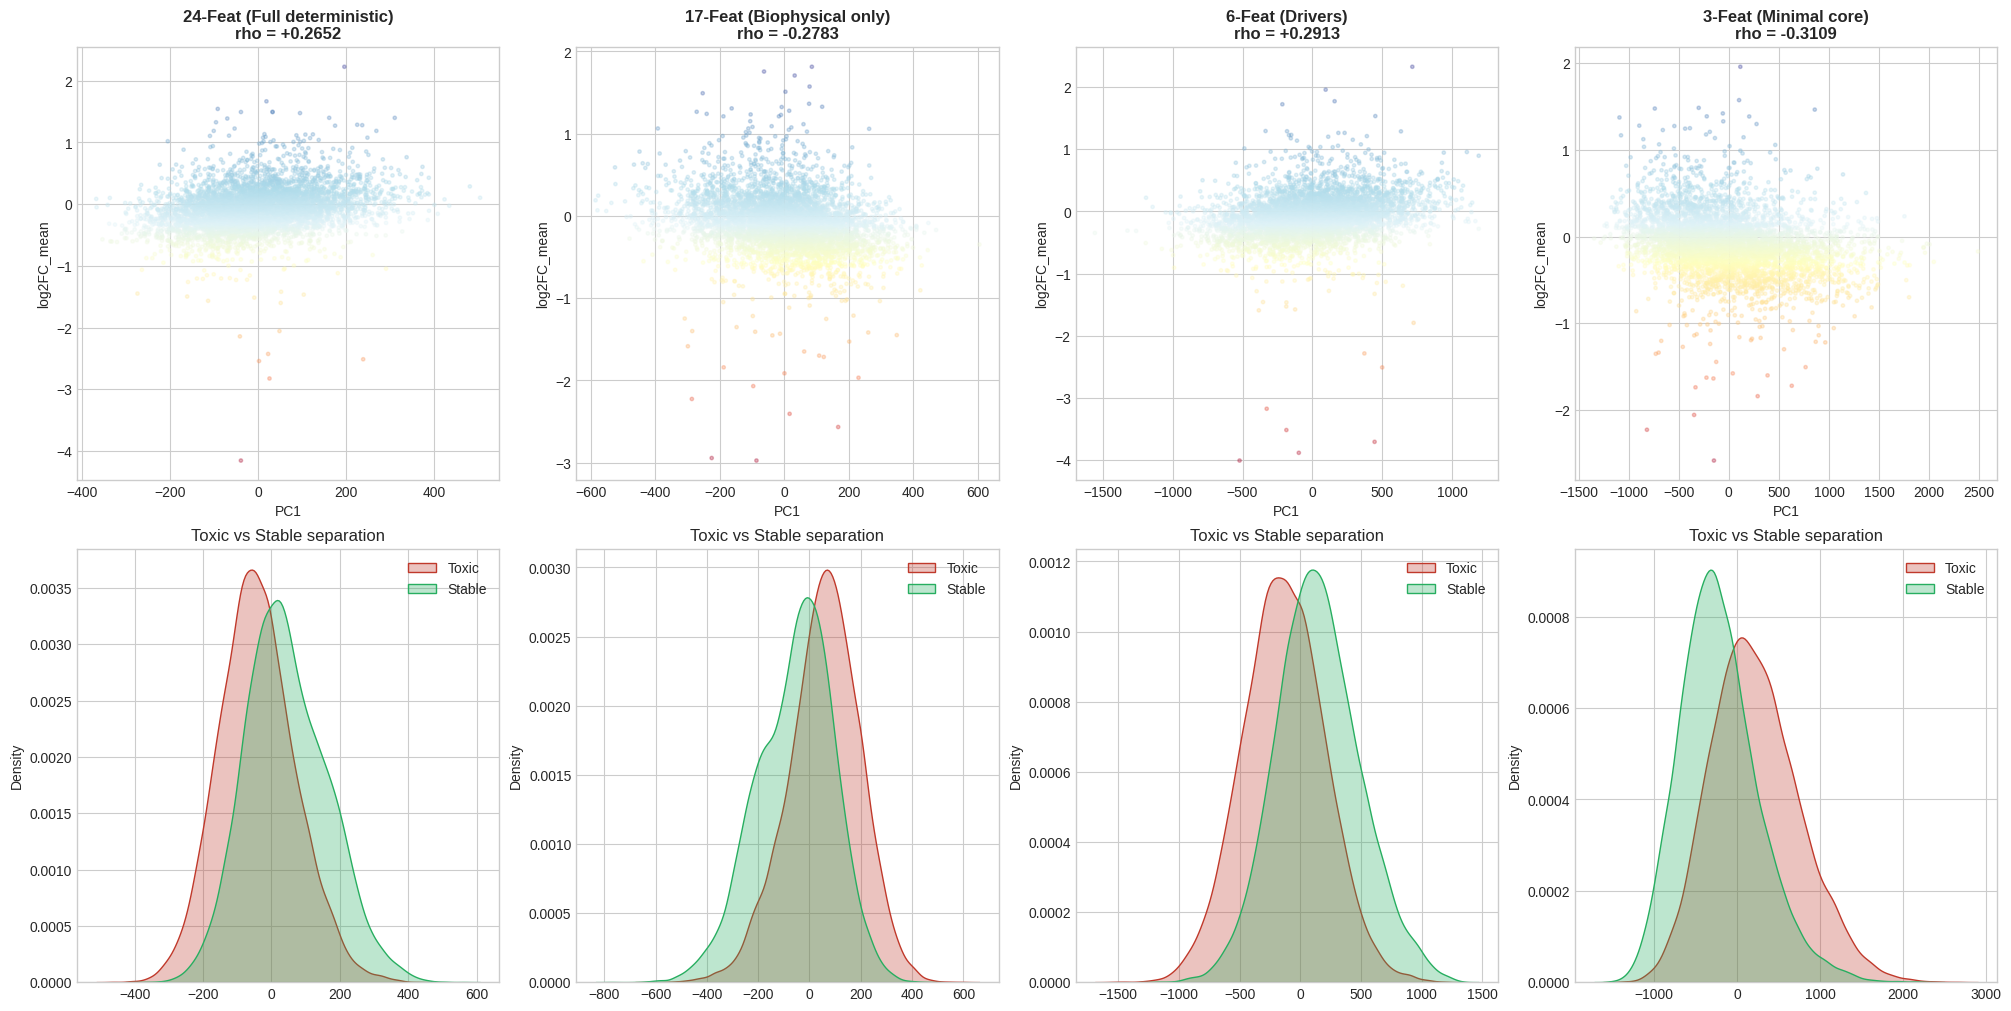


TIER                             | FEATS  | rho (signed)  | CV mean ± std     
-----------------------------------------------------------------------------------------------
24-Feat (Full deterministic)     | 24     | +0.2652      | +0.265 ± 0.003    
17-Feat (Biophysical only)       | 17     | -0.2783      | -0.278 ± 0.002    
6-Feat (Drivers)                 | 6      | +0.2913      | +0.291 ± 0.003    
3-Feat (Minimal core)            | 3      | -0.3109      | -0.311 ± 0.003    
Signed rho — sign-flips between tiers are expected and don't matter for
downstream burden interpretation. Investigate any tier whose sign disagrees
with the rest. The 3-feature minimal tier should outperform the full panel
(replicating v1.5 finding) — if it doesn't, your feature scaling is off.


In [24]:
# =====================================================================
# @title Section 4, Cell 20: Model Reduction Analysis (v2.1, unsupervised)
# =====================================================================
# Tests how unsupervised PC1 (from a fresh SVD on each tier's feature set)
# correlates with log2FC_mean as we remove features. The full v1.5 finding
# was that the 3-feature core (Max_Homo, Entropy, AT_tract) outperforms
# the full feature panel — adding more features dilutes the signal.
#
# Only deterministic biophysical features are used. Learned features
# (CNN_Score, UMAP coords, PC1) are excluded — including them would be
# circular (they were derived from earlier SVD/CNN fits using the labels).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print("--- Model reduction analysis (unsupervised tiers) ---")

# Strictly biophysical / deterministic features; no learned scores.
biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]

features_full     = biophys_all + computed_det
features_hardware = biophys_all
features_drivers  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                                  'GC_percent', 'mRNA_Stability'] if f in df_train.columns]
features_minimal  = [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns]

tiers = {
    f'{len(features_full)}-Feat (Full deterministic)': features_full,
    f'{len(features_hardware)}-Feat (Biophysical only)': features_hardware,
    f'{len(features_drivers)}-Feat (Drivers)':           features_drivers,
    f'{len(features_minimal)}-Feat (Minimal core)':      features_minimal,
}

def evaluate_tier(feats, n_cv=5):
    sc = StandardScaler()
    X_mech = sc.fit_transform(df_train[feats])
    sf = X_train_sp.shape[1] / max(1, X_mech.shape[1])
    X_comb = hstack([X_train_sp, csr_matrix(X_mech * sf)])

    svd_full = TruncatedSVD(n_components=2, random_state=42)
    pc1 = svd_full.fit_transform(X_comb)[:, 0]
    rho_full, _ = spearmanr(pc1, df_train['log2FC_mean'])

    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr, te in kf.split(X_comb):
        s = TruncatedSVD(n_components=2, random_state=42)
        s.fit(X_comb[tr])
        pc1_te = s.transform(X_comb[te])[:, 0]
        r, _ = spearmanr(pc1_te, df_train['log2FC_mean'].iloc[te])
        cv_rhos.append(r)
    return {
        'n_features': len(feats),
        'rho_full':   rho_full,
        'cv_mean':    float(np.mean(cv_rhos)),
        'cv_std':     float(np.std(cv_rhos)),
        'pc1':        pc1,
    }

results = {}
for label, feats in tiers.items():
    print(f"  Processing {label} ({len(feats)} features)...")
    results[label] = evaluate_tier(feats)

# Plot
n_tiers = len(results)
fig, axes = plt.subplots(2, n_tiers, figsize=(5 * n_tiers, 10), layout='constrained')
plot_rng = np.random.default_rng(42)
for col, (label, r) in enumerate(results.items()):
    samp = plot_rng.choice(len(r['pc1']), size=min(5000, len(r['pc1'])), replace=False)
    ax = axes[0, col]
    ax.scatter(r['pc1'][samp], df_train['log2FC_mean'].iloc[samp],
               c=df_train['log2FC_mean'].iloc[samp], cmap='RdYlBu', s=6, alpha=0.3)
    ax.set_title(f"{label}\nrho = {r['rho_full']:+.4f}", fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('log2FC_mean')

    ax2 = axes[1, col]
    quartiles = pd.qcut(df_train['log2FC_mean'], q=4, labels=['Toxic', 'Q2', 'Q3', 'Stable'])
    for q_l, color in zip(['Toxic', 'Stable'], ['#c0392b', '#27ae60']):
        mask = (quartiles == q_l).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True, color=color, label=q_l, alpha=0.3)
    ax2.set_title('Toxic vs Stable separation'); ax2.legend()
plt.show()

# Report
print("\n" + "=" * 95)
print(f"{'TIER':<32} | {'FEATS':<6} | {'rho (signed)':<13} | {'CV mean ± std':<18}")
print("-" * 95)
for label, r in results.items():
    cv_str = f"{r['cv_mean']:+.3f} ± {r['cv_std']:.3f}"
    print(f"{label:<32} | {r['n_features']:<6} | {r['rho_full']:+.4f}      | {cv_str:<18}")
print("=" * 95)
print("Signed rho — sign-flips between tiers are expected and don't matter for")
print("downstream burden interpretation. Investigate any tier whose sign disagrees")
print("with the rest. The 3-feature minimal tier should outperform the full panel")
print("(replicating v1.5 finding) — if it doesn't, your feature scaling is off.")

--- Combined validation suite ---

[1/3] Projecting unsupervised tiers onto df_test...
  24-Feat (Full det.): aligned rho on df_test = +0.3226
  17-Feat (Biophysical): aligned rho on df_test = +0.3316
  6-Feat (Drivers): aligned rho on df_test = +0.3383
  3-Feat (Minimal): aligned rho on df_test = +0.3282

[2/3] Running validation tests on each predictor...
  validating 24-Feat (Full det.)...
  validating 17-Feat (Biophysical)...
  validating 6-Feat (Drivers)...
  validating 3-Feat (Minimal)...
  validating SUPERVISED STACK (Cell 18)...

[3/3] Comparison table (all predictors evaluated on df_test):

Predictor                                rho               95% CI      R^2   Cohen d   Z null      p_emp
---------------------------------------------------------------------------------------------------------
SUPERVISED STACK (Cell 18)           +0.4019     [+0.391, +0.412]  +0.1318    +1.397    +62.2     0.0000
6-Feat (Drivers)                     +0.3383     [+0.327, +0.349] -1589123.40

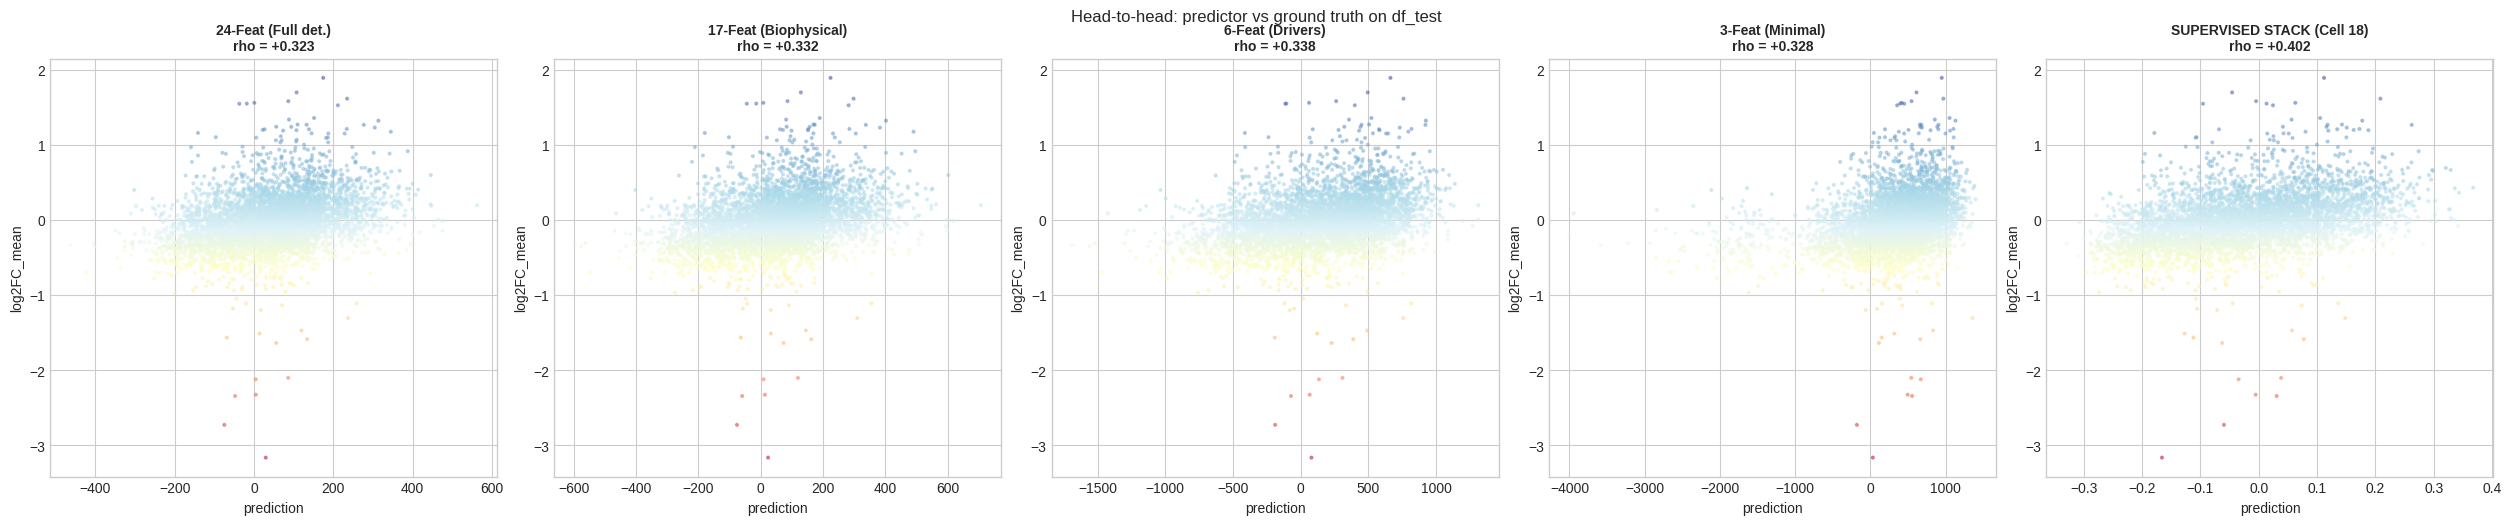


  validation_results dataframe saved to globals.


In [25]:
# =====================================================================
# @title Cell 21: Combined Validation Suite (supervised + unsupervised tiers)
# =====================================================================
# Runs the full v1.5 Phase 50 validation suite on:
#   - The supervised stack (df_test predictions from Cell 18)
#   - Each unsupervised reduction tier (PC1 from Cell 21, evaluated on df_test)
#
# Reports a unified comparison table at the end so the supervised vs
# unsupervised gap is explicit. This is the cell you cite for the
# "head-to-head: supervised covers X% of variance vs unsupervised" claim.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

print("--- Combined validation suite ---")

# ── 1. PROJECT EACH UNSUPERVISED TIER ONTO df_test ──────────────────────
# Cell 21 fit SVD per tier on df_train. We need PC1 on df_test for the
# same tiers, train-fit-only, so we can compare them to the supervised
# stack on the SAME held-out test set.
print("\n[1/3] Projecting unsupervised tiers onto df_test...")

biophys_all = [f for f in SCALER_FEATURES if f in df_train.columns]
computed_det = [f for f in (enriched_features if 'enriched_features' in globals() else [])
                if f in df_train.columns
                and f not in {'CNN_Score', 'UMAP_1', 'UMAP_2'}]

tier_features = {
    f'{len(biophys_all + computed_det)}-Feat (Full det.)': biophys_all + computed_det,
    f'{len(biophys_all)}-Feat (Biophysical)':              biophys_all,
    f'{len([f for f in ["Max_Homo","Entropy","AT_tract","HNS_Affinity","GC_percent","mRNA_Stability"] if f in df_train.columns])}-Feat (Drivers)':
        [f for f in ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
                     'GC_percent', 'mRNA_Stability'] if f in df_train.columns],
    f'{len([f for f in ["Max_Homo","Entropy","AT_tract"] if f in df_train.columns])}-Feat (Minimal)':
        [f for f in ['Max_Homo', 'Entropy', 'AT_tract'] if f in df_train.columns],
}

tier_test_pc1 = {}
for label, feats in tier_features.items():
    sc = StandardScaler()
    X_mech_tr = sc.fit_transform(df_train[feats])
    X_mech_te = sc.transform(df_test[feats])
    sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
    X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
    X_comb_te = hstack([X_test_sp,  csr_matrix(X_mech_te * sf)])
    svd_t = TruncatedSVD(n_components=2, random_state=42)
    svd_t.fit(X_comb_tr)
    pc1_te = svd_t.transform(X_comb_te)[:, 0]
    # Sign-align to match log2FC (descending): if rho is negative, flip sign.
    rho_check, _ = spearmanr(pc1_te, y_te)
    if rho_check < 0:
        pc1_te = -pc1_te
    tier_test_pc1[label] = pc1_te
    print(f"  {label}: aligned rho on df_test = {abs(rho_check):+.4f}")

# Also include the supervised stack as a "tier" for the comparison table
all_predictors = {**tier_test_pc1, 'SUPERVISED STACK (Cell 18)': df_test['stack_pred'].values}

# ── 2. SHARED VALIDATION FUNCTION ───────────────────────────────────────
print("\n[2/3] Running validation tests on each predictor...")

def validate_predictor(pred, y, name, n_boot=1000, n_perm=1000, rng_seed=42):
    """Returns dict of validation metrics for one predictor on df_test."""
    rng = np.random.default_rng(rng_seed)
    n = len(y)

    rho, rho_p   = spearmanr(pred, y)
    pear, pear_p = pearsonr(pred, y)
    r2  = r2_score(y, pred) if not np.isnan(np.std(pred)) and np.std(pred) > 0 else np.nan
    mae = mean_absolute_error(y, pred)

    # Bootstrap CI on rho
    boot = np.empty(n_boot, dtype=np.float32)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i], _ = spearmanr(pred[idx], y[idx])
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    # Permutation null
    null = np.empty(n_perm, dtype=np.float32)
    for i in range(n_perm):
        null[i], _ = spearmanr(pred, rng.permutation(y))
    null_mean, null_std = float(null.mean()), float(null.std())
    z = (rho - null_mean) / max(null_std, 1e-9)
    p_emp = float((np.abs(null) >= abs(rho)).mean())

    # Cohen's d on prediction tiers
    top    = pred >= np.quantile(pred, 0.90)
    bottom = pred <= np.quantile(pred, 0.10)
    pooled = np.sqrt((y[top].var(ddof=1) + y[bottom].var(ddof=1)) / 2)
    d = (y[top].mean() - y[bottom].mean()) / max(pooled, 1e-9)

    # Heteroscedasticity
    het, _ = spearmanr(np.abs(y - pred), np.abs(pred)) if r2 != np.nan else (np.nan, np.nan)

    # Calibration slope
    if np.std(pred) > 0:
        slope, intercept = np.polyfit(pred, y, 1)
    else:
        slope, intercept = np.nan, np.nan

    return {
        'name':           name,
        'spearman_rho':   float(rho),
        'rho_p':          float(rho_p),
        'pearson_r':      float(pear),
        'r2':             float(r2),
        'mae':            float(mae),
        'ci_95_lo':       float(ci_lo),
        'ci_95_hi':       float(ci_hi),
        'null_mean':      null_mean,
        'null_std':       null_std,
        'z_score':        float(z),
        'perm_p_emp':     p_emp,
        'cohens_d':       float(d),
        'heteroscedasticity_rho': float(het) if not np.isnan(het) else np.nan,
        'calibration_slope':      float(slope) if not np.isnan(slope) else np.nan,
    }

results = {}
for name, pred in all_predictors.items():
    print(f"  validating {name}...")
    results[name] = validate_predictor(pred, y_te, name)

# ── 3. UNIFIED COMPARISON TABLE ─────────────────────────────────────────
print("\n[3/3] Comparison table (all predictors evaluated on df_test):")

comp_df = pd.DataFrame(results).T
comp_df = comp_df.sort_values('spearman_rho', ascending=False)
print()
print(f"{'Predictor':<35} {'rho':>8} {'95% CI':>20} {'R^2':>8} {'Cohen d':>9} {'Z null':>8} {'p_emp':>10}")
print("-" * 105)
for _, r in comp_df.iterrows():
    ci = f"[{r['ci_95_lo']:+.3f}, {r['ci_95_hi']:+.3f}]"
    print(f"{r['name']:<35} {r['spearman_rho']:>+8.4f} {ci:>20} "
          f"{r['r2']:>+8.4f} {r['cohens_d']:>+9.3f} {r['z_score']:>+8.1f} {r['perm_p_emp']:>10.4f}")

# Head-to-head: supervised vs best unsupervised
sup_rho = results['SUPERVISED STACK (Cell 18)']['spearman_rho']
unsup_rhos = {k: v['spearman_rho'] for k, v in results.items() if k != 'SUPERVISED STACK (Cell 18)'}
best_unsup_name = max(unsup_rhos, key=unsup_rhos.get)
best_unsup_rho = unsup_rhos[best_unsup_name]
coverage = (best_unsup_rho / sup_rho) * 100 if sup_rho > 0 else np.nan

print(f"\n  HEAD-TO-HEAD:")
print(f"    Supervised stack rho:           {sup_rho:+.4f}")
print(f"    Best unsupervised tier rho:     {best_unsup_rho:+.4f}  ({best_unsup_name})")
print(f"    Unsupervised covers {coverage:.0f}% of supervised performance")
print(f"    Gap (Layer 4 contribution):     {sup_rho - best_unsup_rho:+.4f}")

# Replicate-quality ceiling
if 'log2FC_std' in df_test.columns:
    print(f"\n  REPLICATE-QUALITY CEILING:")
    cleanest = df_test['log2FC_std'] <= df_test['log2FC_std'].quantile(0.25)
    sup_clean, _ = spearmanr(df_test.loc[cleanest, 'stack_pred'], y_te[cleanest.values])
    print(f"    Supervised rho on cleanest 25% replicates: {sup_clean:+.4f}")
    print(f"    This is your effective ceiling on this dataset.")

# Optional: scatter plot grid of every predictor
fig, axes = plt.subplots(1, len(all_predictors), figsize=(5 * len(all_predictors), 5),
                         layout='constrained')
plot_rng = np.random.default_rng(42)
samp = plot_rng.choice(len(y_te), size=min(5000, len(y_te)), replace=False)
for ax, (name, pred) in zip(axes, all_predictors.items()):
    ax.scatter(pred[samp], y_te[samp], c=y_te[samp], cmap='RdYlBu', s=4, alpha=0.4)
    rho_p = results[name]['spearman_rho']
    ax.set_title(f"{name}\nrho = {rho_p:+.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('prediction'); ax.set_ylabel('log2FC_mean')
plt.suptitle('Head-to-head: predictor vs ground truth on df_test', y=1.02)
plt.show()

# Persist for downstream
validation_results = comp_df
print("\n  validation_results dataframe saved to globals.")

In [28]:
# =====================================================================
# @title Cell 22: Predictor — Single-Sequence Inference
# =====================================================================
# @markdown Paste a 172bp DNA sequence below to evaluate it against the population baseline.
# @markdown The models must already be trained in the previous cells.

import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr, percentileofscore

# ── ENTRY POINT (TEXTBOX OVERLAY) ───────────────────────────────────────
# Paste your sequence here:
oracle_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG" # @param {type:"string"}

print("--- Predictor: single-sequence inference ---")
print(f"Input sequence length: {len(oracle_seq)} bp")

# ── FEATURE COMPUTATION ─────────────────────────────────────────────────
def featurise_oracle(seq):
    """Compute every active feature for one sequence. Returns a 1-row DataFrame."""
    # Ensure sequence is clean
    seq = seq.strip().upper()

    # Base biophysical features (Cell 5)
    feats = calculate_master_features(seq)

    # Advanced Biomarkers (Cells 7-10)
    if 'compute_cai' in globals():            feats['CAI_Score']      = compute_cai(seq)
    if 'initiation_mfe_proxy' in globals():   feats['mRNA_MFE']       = initiation_mfe_proxy(seq)
    if 'scan_direct_repeats' in globals():    feats['Max_Repeat_Len'] = scan_direct_repeats(seq)
    if 'count_codon_stalls' in globals():     feats['Codon_Stalls']   = count_codon_stalls(seq)

    # Numba kernels for hairpin / hns (Cell 9)
    if 'encode_sequences' in globals() and '_hairpin_one' in globals():
        seq_int = encode_sequences(pd.Series([seq]))[0]
        feats['Min_Hairpin_dG'] = float(_hairpin_one(seq_int, NN_DG))
        feats['HNS_Coverage']   = float(_hns_one(seq_int))

    # Flux_Score logic
    feats['Flux_Score'] = (feats.get('CAI_Score', 0.0) * 20
                           + feats.get('Promoter_Str', 0.0) * 30)

    # CNN_Score (Cell 11/12)
    if 'model_cnn' in globals() and 'one_hot_encode' in globals():
        seq_oh = one_hot_encode([seq])
        feats['CNN_Score'] = float(model_cnn.predict(seq_oh, verbose=0)[0, 0])

    # UMAP coordinates (Cell 12) - FIXED to include IHF/CRP invariants for the Scaler
    if 'reducer' in globals() and 'fitted_scaler' in globals():
        # Get the original feature list the scaler was fit on
        scaler_input_feats = list(fitted_scaler.feature_names_in_)

        # Build the input row including dropped invariants
        bio_only = pd.DataFrame([{f: feats.get(f, 0.0) for f in scaler_input_feats}])

        # Transform and reduce
        bio_scaled = fitted_scaler.transform(bio_only[scaler_input_feats])
        umap_coords = reducer.transform(bio_scaled)[0]
        feats['UMAP_1'], feats['UMAP_2'] = float(umap_coords[0]), float(umap_coords[1])

    return pd.DataFrame([feats])

print("  Featurising...")
oracle_features = featurise_oracle(oracle_seq)

# Verify all expected columns for supervised model are present
missing = [f for f in supervised_features if f not in oracle_features.columns]
if missing:
    for f in missing:
        oracle_features[f] = float(df_train[f].mean()) if f in df_train.columns else 0.0
    print(f"  WARN: filled {len(missing)} missing features from train mean: {missing}")

# ── 1. SUPERVISED STACK PREDICTION ──────────────────────────────────────
print("\n[1/3] Supervised stack prediction...")

X_oracle = oracle_features[supervised_features].values.astype(np.float32)

# Base learners
base_oracle = {
    'xgb':    float(base_models['xgb'].predict(X_oracle)[0]),
    'cat':    float(base_models['cat'].predict(X_oracle)[0]),
    'ranker': float(base_models['ranker'].predict(X_oracle)[0]),
}

# Apply Meta-Learner (Ridge)
oracle_stack = np.array([[base_oracle['xgb'], base_oracle['cat'], base_oracle['ranker']]], dtype=np.float32)
oracle_stack_s = stacking['meta_scaler'].transform(oracle_stack)
sup_pred = float(stacking['meta'].predict(oracle_stack_s)[0])

# Population percentile
sup_percentile = percentileofscore(df_train['log2FC_mean'].values, sup_pred, kind='mean')
print(f"  Supervised stack predicted log2FC: {sup_pred:+.4f}")
print(f"  Population percentile: {sup_percentile:.1f}%")

# ── 2. UNSUPERVISED TIER PREDICTIONS ────────────────────────────────────
print("\n[2/3] Unsupervised tier predictions...")

def project_oracle_onto_tier(seq_features, feats):
    """Refit a tier-specific scaler+SVD on df_train, project the oracle row."""
    sc = StandardScaler()
    X_mech_tr = sc.fit_transform(df_train[feats])
    X_mech_or = sc.transform(seq_features[feats])

    # Build the oracle k-mer sparse row
    oracle_kmers = " ".join(
        f"BIN{min(int(i / (len(oracle_seq) / 5)), 4):02d}_{oracle_seq[i:i+4]}"
        for i in range(len(oracle_seq) - 3)
    )
    oracle_sp = fitted_vec.transform([oracle_kmers])

    sf = X_train_sp.shape[1] / max(1, X_mech_tr.shape[1])
    X_comb_tr = hstack([X_train_sp, csr_matrix(X_mech_tr * sf)])
    X_comb_or = hstack([oracle_sp,  csr_matrix(X_mech_or * sf)])

    svd_t = TruncatedSVD(n_components=2, random_state=42)
    svd_t.fit(X_comb_tr)
    pc1_or = float(svd_t.transform(X_comb_or)[0, 0])

    # Sign-align
    pc1_train = svd_t.transform(X_comb_tr)[:, 0]
    rho_align, _ = spearmanr(pc1_train, df_train['log2FC_mean'])
    if rho_align < 0:
        pc1_or = -pc1_or
        pc1_train = -pc1_train

    slope, intercept = np.polyfit(pc1_train, df_train['log2FC_mean'].values, 1)
    return float(slope * pc1_or + intercept)

tier_oracle = {}
for label, feats in tier_features.items():
    pred = project_oracle_onto_tier(oracle_features, feats)
    pct = percentileofscore(df_train['log2FC_mean'].values, pred, kind='mean')
    tier_oracle[label] = {'pred': pred, 'pct': pct}
    print(f"  {label:<25} : log2FC = {pred:+.3f} ({pct:.1f}%)")

# ── 3. PERMUTATION-BASED p-VALUE ────────────────────────────────────────
print("\n[3/3] Permutation p-value (significance vs population)...")

n_perm = 1000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df_train), size=n_perm, replace=False)

# Get predictions for 1000 random sequences to build a null distribution
train_X = df_train[supervised_features].values[sample_idx].astype(np.float32)
train_base_preds = np.column_stack([
    base_models['xgb'].predict(train_X),
    base_models['cat'].predict(train_X),
    base_models['ranker'].predict(train_X),
])
train_stack_preds = stacking['meta'].predict(stacking['meta_scaler'].transform(train_base_preds))

# One-sided p-value
if sup_pred < df_train['log2FC_mean'].median():
    p_val = float((train_stack_preds <= sup_pred).mean())
    direction = "toxic"
else:
    p_val = float((train_stack_preds >= sup_pred).mean())
    direction = "stable"

# ── REPORT ──────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(" FINAL PREDICTION REPORT")
print("=" * 72)
print(f"  Sequence: {oracle_seq[:50]}...")
print(f"  Result  : {sup_pred:+.4f} log2FC (p = {p_val:.4f})")
print(f"  Verdict : {'SIGNIFICANTLY ' if p_val < 0.05 else ''}{direction.upper()}")
print("=" * 72)

--- Predictor: single-sequence inference ---
Input sequence length: 172 bp
  Featurising...

[1/3] Supervised stack prediction...
  Supervised stack predicted log2FC: -0.0980
  Population percentile: 47.5%

[2/3] Unsupervised tier predictions...
  24-Feat (Full det.)       : log2FC = -0.037 (56.6%)
  17-Feat (Biophysical)     : log2FC = -0.058 (53.5%)
  6-Feat (Drivers)          : log2FC = -0.015 (59.8%)
  3-Feat (Minimal)          : log2FC = +0.002 (62.3%)

[3/3] Permutation p-value (significance vs population)...

 FINAL PREDICTION REPORT
  Sequence: AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATAT...
  Result  : -0.0980 log2FC (p = 0.4500)
  Verdict : TOXIC
